In [246]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

O sistema de EDO que contem os parâmetros de interesse é o seguinte:

\begin{equation}\notag
\begin{align}
\frac{dn_5}{dt}
&=
\sigma P F(t)\, n_4
- W_{51} n_1 n_5
- W_{52} n_2 n_5
- k_{54} n_5,
\\[8pt]
\frac{dn_2}{dt}
&=
W_{51} n_1 n_5
- W_{52} n_2 n_5
- k_{21} n_2,
\\[8pt]
\frac{dn_3}{dt}
&=
W_{52} n_2 n_5
- k_{31} n_3.
\end{align}
\end{equation}

### Dados experimentais

In [247]:
from treament_tcspc_data import fetch_data_filenames, extract_data_info_from_path, time_domain_visual_verification
# from snr_aux_functions import get_snr_db, plot_time_and_freq_domain

In [248]:
filenames_all = fetch_data_filenames("./experimental_data/")

In [249]:
# filenames_all = fetch_data_filenames("./23-05-26")
exc_data_npy = [
    extract_data_info_from_path(data_path_npy) for data_path_npy in filenames_all 
    if ("step" in data_path_npy) and (".npy" in data_path_npy) and ("exc_laser" in data_path_npy)
    ]

In [250]:
#Populate particle list

num_particles = 30
p_list = [
    {
        "p_label": p_id+1,
        "p_data": [
            extract_data_info_from_path(p_data_path)
            for p_data_path in filenames_all
            if (f"p{p_id+1}_lum" in p_data_path) and ("step" in p_data_path) and (".npy" in p_data_path)
        ]
    }
    for p_id in range(num_particles) if p_id == 12
]

In [251]:
# time_domain_visual_verification(p_list)

In [252]:
data_test = np.array([freq_data for freq_data in p_list[0]["p_data"] if freq_data["freq"] == 1000 ][0]["data"])

(100, 196, 2)


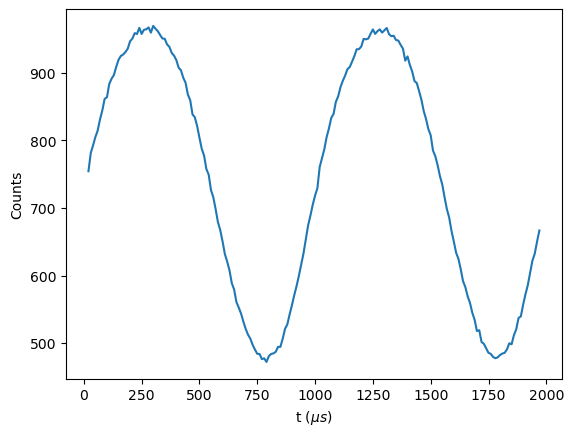

In [253]:
print(data_test.shape)

plt.plot(
    data_test[0,:,0],
    data_test[:,:,1].mean(axis=0),
)
plt.ylabel("Counts")
plt.xlabel("t ($\mu s$)")
plt.show()

### Simulação

In [254]:
# 1. Constantes Físicas (Valores consolidados para Y2O3)
n1 = 2.3e20 #população de Er3+ (cm^-3)
n4 = 1.3e21 #população de Yb3+ (cm^-3)
k54 = 1279.0  # s^-1
k31 = 192.0   # s^-1
k21 = 16.66   # s^-1
sigma = 1.75e-20 # cm^2
P = 5.4e20    # fótons / (cm^2 * s) (baseado em 110 W/cm^2)

#Estimativa inicial
W51 = 1e-17
W52 = W51

amplitude = 0.5
offset = 0.8

# Diferença de fase experimental freq, ph_diff, error_pd
# Exemplo com 3 frequências extraídas da sua Figura 12
pd = np.array([[ 1.00000000e+00, -2.78640057e-03,  3.36729982e-03],
       [ 2.00000000e+00, -2.94542499e-03,  3.30445647e-03],
       [ 3.00000000e+00, -5.70062310e-03,  2.22292791e-03],
       [ 5.00000000e+00, -1.15347657e-03,  3.38780739e-03],
       [ 7.00000000e+00, -1.14123889e-02,  3.33181254e-03],
       [ 1.00000000e+01, -7.57860157e-03,  3.31657015e-03],
       [ 2.00000000e+01, -1.25420350e-02,  3.19388745e-03],
       [ 3.00000000e+01, -1.16159364e-02,  3.66126559e-03],
       [ 5.00000000e+01, -2.39443326e-02,  3.09906367e-03],
       [ 7.00000000e+01, -3.15226287e-02,  2.85755006e-03],
       [ 1.00000000e+02, -5.28665836e-02,  3.35273380e-03],
       [ 2.00000000e+02, -8.30688285e-02,  2.73059639e-03],
       [ 3.00000000e+02, -1.33267253e-01,  4.03296653e-03],
       [ 5.00000000e+02, -2.24394939e-01,  3.47703795e-03],
       [ 7.00000000e+02, -3.65668758e-01,  3.51463917e-03],
       [ 1.00000000e+03, -4.71239925e-01,  3.47630975e-03],
       [ 2.00000000e+03, -6.40636375e-01,  3.75070348e-03],
       [ 3.00000000e+03, -8.06144725e-01,  3.44250145e-03],
       [ 5.00000000e+03, -9.67168365e-01,  2.84889823e-03],
       [ 7.00000000e+03, -1.18290875e+00,  3.72268580e-03],
       [ 1.00000000e+04, -1.34746600e+00,  4.92232407e-03],
       [ 2.00000000e+04, -1.40335577e+00,  8.13990120e-03],
       [ 3.00000000e+04, -1.48759587e+00,  1.57209815e-02],
       [ 5.00000000e+04, -1.34833651e+00,  2.13302156e-02],
       [ 7.00000000e+04, -1.28640332e+00,  3.61040996e-02],
       [ 1.00000000e+05, -1.23208184e+00,  6.92253145e-02]])

In [255]:
def odes(t, n, W51, W52, freq):
    n5, n2, n3 = n
    omega = 2 * np.pi * freq
    
    # Função do laser conforme seus dados experimentais
    F_t = offset + amplitude * np.cos(omega * t)
    
    # Prevenção numérica: a intensidade não pode ser negativa
    if F_t < 0: F_t = 0.0 
    
    dn5_dt = sigma * P * F_t * n4 - W51 * n1 * n5 - W52 * n2 * n5 - k54 * n5
    dn2_dt = W51 * n1 * n5 - W52 * n2 * n5 - k21 * n2
    dn3_dt = W52 * n2 * n5 - k31 * n3
    
    return [dn5_dt, dn2_dt, dn3_dt]

In [ ]:
# 3. Função para Extrair a Fase via FFT
def extrair_fase(t, n3, freq):
    # DICA CRUCIAL: Descartar a primeira metade da simulação (o transiente)
    # Analisamos apenas a parte onde a onda já estabilizou
    meio = len(t) // 2
    t_estavel = t[meio:]
    n3_estavel = n3[meio:]
    
    # Recria o sinal do laser no mesmo intervalo de tempo para comparação
    laser_estavel = offset + amplitude * np.cos(2 * np.pi * freq * t_estavel)
    
    N = len(t_estavel)
    dt = t_estavel[1] - t_estavel[0]
    
    # Aplica a FFT
    yf_n3 = fft(n3_estavel)
    yf_laser = fft(laser_estavel)
    xf = fftfreq(N, dt)
    
    # Encontra o índice da frequência de modulação (freq) no array da FFT
    idx = np.argmin(np.abs(xf - freq))
    
    # Extrai o ângulo (fase) de ambos os sinais nesse pico de frequência
    fase_n3 = np.angle(yf_n3[idx])
    fase_laser = np.angle(yf_laser[idx])
    
    # Diferença de fase (Luminescência - Laser)
    delta_fase = fase_n3 - fase_laser
    
    # Garante que o valor fique no intervalo correto [-pi, pi]
    delta_fase = np.angle(np.exp(1j * delta_fase))
    
    return delta_fase

In [257]:
pd_simulated = []
num_points = len(pd)

for freq in pd[:num_points,0]:

    #define as EDOS
    def odes(t, n, W51, W52, freq):
        n5, n2, n3 = n
        omega = 2 * np.pi * freq
        
        # Função do laser conforme seus dados experimentais
        F_t = offset + amplitude * np.cos(omega * t)
        
        # Prevenção numérica: a intensidade não pode ser negativa
        if F_t < 0: F_t = 0.0 
        
        dn5_dt = sigma * P * F_t * n4 - W51 * n1 * n5 - W52 * n2 * n5 - k54 * n5
        dn2_dt = W51 * n1 * n5 - W52 * n2 * n5 - k21 * n2
        dn3_dt = W52 * n2 * n5 - k31 * n3
        
        return [dn5_dt, dn2_dt, dn3_dt]
    
    t_span = (0, 1/freq * 500) # Simula alguns ciclos
    # W51 = 1e-20
    # W52 = 1e-20
    y0 = [0, 0, 0]

    t_eval = np.linspace(t_span[0], t_span[-1], 10000)

    sol = solve_ivp(
        odes, 
        t_span, 
        y0, 
        t_eval=t_eval,
        args=(W51, W52, freq),
        method="Radau"
        )
    
    n3 = sol.y[2]
    
    pd_simulated.append(
        [freq, extrair_fase(sol.t, n3, freq)]
        )
    
pd_simulated = np.array(pd_simulated)

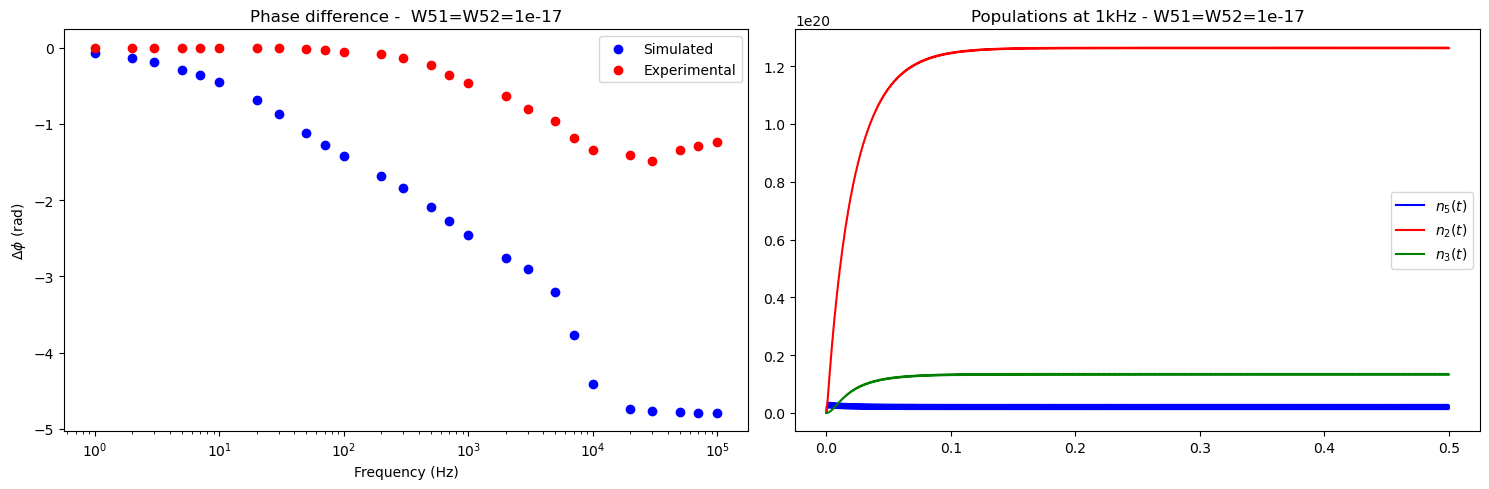

In [258]:
_, axs = plt.subplots(1,2, figsize=(15,5))

axs[0].scatter(pd_simulated[:,0], np.unwrap(pd_simulated[:,1]), color="blue", label="Simulated")
axs[0].scatter(pd[:num_points,0], pd[:num_points,1], color="red", label="Experimental")
axs[0].set_title("Phase difference - " + f" W51=W52={W51:.2}")
axs[0].set_ylabel("$\Delta \phi$ (rad)")
axs[0].set_xlabel("Frequency (Hz)")
axs[0].set_xscale("log")
axs[0].legend(loc="best")
# plt.legend()

# Plot para 1kHz
f=1000
t_span = (0, 1/f * 500) # Simula alguns ciclos

y0 = [0, 0, 0]

t_eval = np.linspace(t_span[0], t_span[-1], 10000)

sol_1kHz = solve_ivp(
    odes, 
    t_span, 
    y0, 
    t_eval=t_eval,
    args=(W51, W52, f),
    # method="BDF",
    method="Radau",
    )

axs[1].plot(sol_1kHz.t, sol_1kHz.y[0], "blue", label="$n_5(t)$")
axs[1].plot(sol_1kHz.t, sol_1kHz.y[1], "red" ,label="$n_2(t)$")
axs[1].plot(sol_1kHz.t, sol_1kHz.y[2], "green" ,label="$n_3(t)$")
axs[1].set_title("Populations at 1kHz -" + f" W51=W52={W51:.2}")
axs[1].legend(loc="best")

plt.tight_layout()
plt.show()


### Ajuste numérico

In [259]:

# 4. Função Residual para o Otimizador
def funcao_custo(parametros, freq_exp, fase_exp):
    W51, W52 = parametros
    fases_calculadas = []
    
    # Penalidade severa se o otimizador tentar testar valores negativos para W
    if W51 < 0 or W52 < 0:
        return np.ones_like(fase_exp) * 1e6
        
    for f in freq_exp:
        t_span = (0, 1/f * 20) # 20 ciclos garante que o transiente morra
        t_eval = np.linspace(t_span[0], t_span[1], 2000)
        
        sol = solve_ivp(
            odes, t_span, [0, 0, 0], 
            args=(W51, W52, f), 
            method='BDF', t_eval=t_eval, rtol=1e-6, atol=1e-9
        )
        
        # Pega a população de n3 (índice 2)
        n3 = sol.y[2]
        
        fase_calc = extrair_fase(sol.t, n3, f)
        fases_calculadas.append(fase_calc)
        
    fases_calculadas = np.array(fases_calculadas)
    
    # O Least Squares tentará minimizar essa diferença
    return fases_calculadas - fase_exp

# =====================================================================
# 5. EXECUÇÃO DO AJUSTE (Insira seus arrays aqui)
# =====================================================================



frequencias_experimentais = pd[:10,0] 
fases_experimentais = pd[:10,1] # Substitua pelos radianos exatos

# Palpite inicial para W51 e W52 (em cm^3 / s)
chute_inicial = [1e-17, 1e-17]

print("Iniciando ajuste numérico. Isso pode levar alguns minutos...")

# Roda o otimizador (pode usar bounds=(0, np.inf) se preferir em vez da penalidade manual)
# resultado = least_squares(
    funcao_custo, 
    chute_inicial, 
    args=(frequencias_experimentais, fases_experimentais),
    bounds=(0, np.inf), # Força valores positivos
    method='trf'
)

print("-" * 30)
print("AJUSTE CONCLUÍDO!")
print(f"W51 encontrado = {resultado.x[0]:.2e} cm³/s")
print(f"W52 encontrado = {resultado.x[1]:.2e} cm³/s")

IndentationError: unexpected indent (681048615.py, line 47)